# 07 — Results & AnalysisDataset
**Invariant proved:** Analysis-Ready Data Interface
**Module built:** `sdk/core/results.py` — `AnalysisDataset`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sdk.core.engine import BranchedSimulationEngine, CounterfactualMode
from sdk.core.scenario import BaseScenario, TimeConfig, Predictions, Interventions, Outcomes

## Define a Simple Stochastic Scenario

Same scenario used in NB04 (step purity contract) — stochastic with correct
RNG stream discipline.

In [2]:
class StochasticPureScenario(BaseScenario[np.ndarray]):
    """Scenario with random draws in step/measure, using correct RNG streams."""
    unit_of_analysis = "entity"

    def create_population(self, n_entities):
        return self.rng.population.random(n_entities)

    def step(self, state, t):
        noise = self.rng.temporal.normal(0, 0.01, size=len(state))
        return np.clip(state + noise, 0, 1)

    def predict(self, state, t):
        noise = self.rng.prediction.normal(0, 0.1, size=len(state))
        return Predictions(scores=state + noise)

    def intervene(self, state, predictions, t):
        treated = predictions.scores > 0.5
        state = state.copy()
        state[treated] *= 0.5
        return state, Interventions(treated_indices=np.where(treated)[0])

    def measure(self, state, t):
        events = (self.rng.outcomes.random(len(state)) < state).astype(float)
        return Outcomes(events=events, entity_ids=np.arange(len(state)))

## 1. Run Simulation

Run with BRANCHED mode to get both factual and counterfactual outcomes.

In [3]:
n_entities = 100
n_timesteps = 20
seed = 42
prediction_schedule = [5, 10, 15]

tc = TimeConfig(
    n_timesteps=n_timesteps,
    timestep_duration=1/52,
    prediction_schedule=prediction_schedule,
)

scenario = StochasticPureScenario(time_config=tc, seed=seed)
engine = BranchedSimulationEngine(scenario, CounterfactualMode.BRANCHED)
results = engine.run(n_entities)

print(f"Simulation complete: {n_entities} entities, {n_timesteps} timesteps")
print(f"Counterfactual mode: {results.counterfactual_mode}")
print(f"Outcome timesteps recorded: {len(results.outcomes)}")
print(f"CF outcome timesteps recorded: {len(results.counterfactual_outcomes)}")
print(f"Prediction timesteps: {sorted(results.predictions.keys())}")
print(f"Intervention timesteps: {sorted(results.interventions.keys())}")

# Convert to AnalysisDataset
ds = results.to_analysis()
print(f"\nAnalysisDataset unit_of_analysis: '{ds.unit_of_analysis}'")

Simulation complete: 100 entities, 20 timesteps
Counterfactual mode: branched
Outcome timesteps recorded: 20
CF outcome timesteps recorded: 20
Prediction timesteps: [5, 10, 15]
Intervention timesteps: [5, 10, 15]

AnalysisDataset unit_of_analysis: 'entity'


## 2. to_time_series()

Export aggregated time series for ITS (Interrupted Time Series) analysis.
Compare factual vs counterfactual trajectories.

Factual time series keys: ['timesteps', 'outcomes', 'treatment_indicator']
  timesteps shape: (20,)
  outcomes shape:  (20,)
  treatment_indicator shape: (20,)


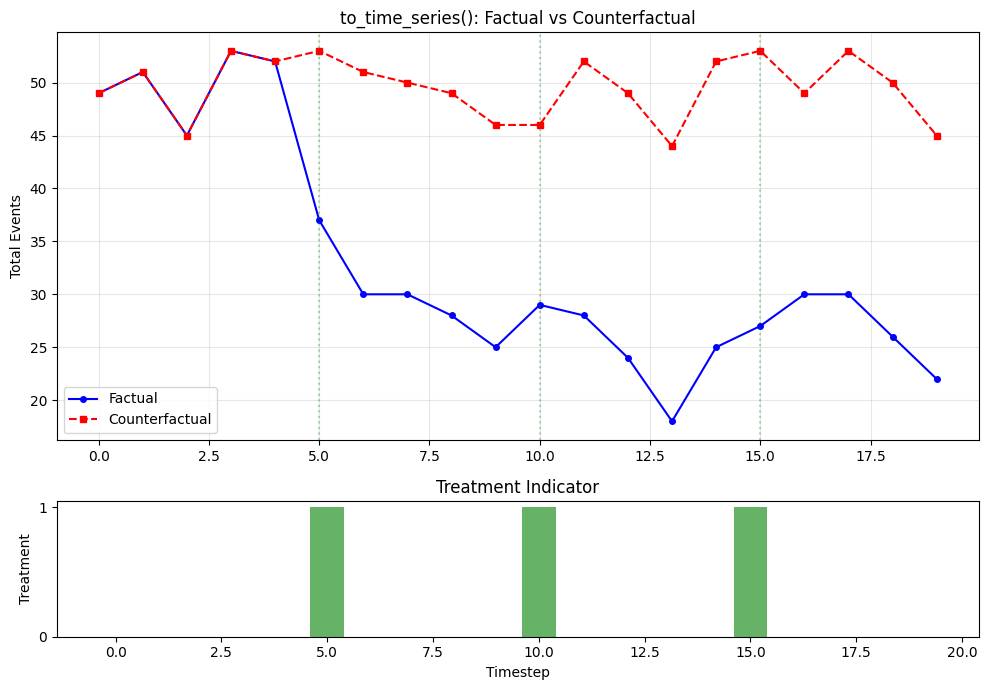

In [4]:
ts_factual = ds.to_time_series(branch='factual')
ts_counter = ds.to_time_series(branch='counterfactual')

print("Factual time series keys:", list(ts_factual.keys()))
print(f"  timesteps shape: {ts_factual['timesteps'].shape}")
print(f"  outcomes shape:  {ts_factual['outcomes'].shape}")
print(f"  treatment_indicator shape: {ts_factual['treatment_indicator'].shape}")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(ts_factual['timesteps'], ts_factual['outcomes'], 'b-o', markersize=4, label='Factual')
ax.plot(ts_counter['timesteps'], ts_counter['outcomes'], 'r--s', markersize=4, label='Counterfactual')
for pt in prediction_schedule:
    ax.axvline(x=pt, color='green', alpha=0.3, linestyle=':')
ax.set_ylabel('Total Events')
ax.set_title('to_time_series(): Factual vs Counterfactual')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.bar(ts_factual['timesteps'], ts_factual['treatment_indicator'], color='green', alpha=0.6)
ax.set_xlabel('Timestep')
ax.set_ylabel('Treatment')
ax.set_title('Treatment Indicator')
ax.set_yticks([0, 1])

plt.tight_layout()
plt.show()

## 3. to_panel()

Export entity-level panel data for DiD (Difference-in-Differences) analysis.
Verify the shape is n_entities * n_timesteps.

In [5]:
panel = ds.to_panel()

print("Panel data keys:", list(panel.keys()))
print(f"  entity_ids shape: {panel['entity_ids'].shape}")
print(f"  timesteps shape:  {panel['timesteps'].shape}")
print(f"  outcomes shape:   {panel['outcomes'].shape}")
print(f"  treated shape:    {panel['treated'].shape}")
print(f"  unit_of_analysis: '{panel['unit_of_analysis']}'")

expected_rows = n_entities * n_timesteps
actual_rows = len(panel['entity_ids'])
print(f"\nExpected rows (n_entities * n_timesteps): {expected_rows}")
print(f"Actual rows: {actual_rows}")
assert actual_rows == expected_rows, f"Shape mismatch: {actual_rows} != {expected_rows}"
print("Shape check PASSED")

unique_entities = np.unique(panel['entity_ids'])
print(f"\nUnique entity_ids: {len(unique_entities)} (first 10: {unique_entities[:10]})")
print(f"Unique timesteps:  {len(np.unique(panel['timesteps']))}")
print(f"Treated entities:  {len(np.unique(panel['entity_ids'][panel['treated'] == 1]))}")

Panel data keys: ['entity_ids', 'timesteps', 'outcomes', 'treated', 'unit_of_analysis']
  entity_ids shape: (2000,)
  timesteps shape:  (2000,)
  outcomes shape:   (2000,)
  treated shape:    (2000,)
  unit_of_analysis: 'entity'

Expected rows (n_entities * n_timesteps): 2000
Actual rows: 2000
Shape check PASSED

Unique entity_ids: 100 (first 10: [0 1 2 3 4 5 6 7 8 9])
Unique timesteps:  20
Treated entities:  60


## 4. to_entity_snapshots()

Export cross-sectional data at a prediction timestep for RDD
(Regression Discontinuity Design) analysis.

Snapshot at t=5:
  entity_ids shape: (100,)
  outcomes shape:   (100,)
  scores type:      <class 'numpy.ndarray'>
  scores shape:     (100,)
  scores range:     [-0.146, 1.087]


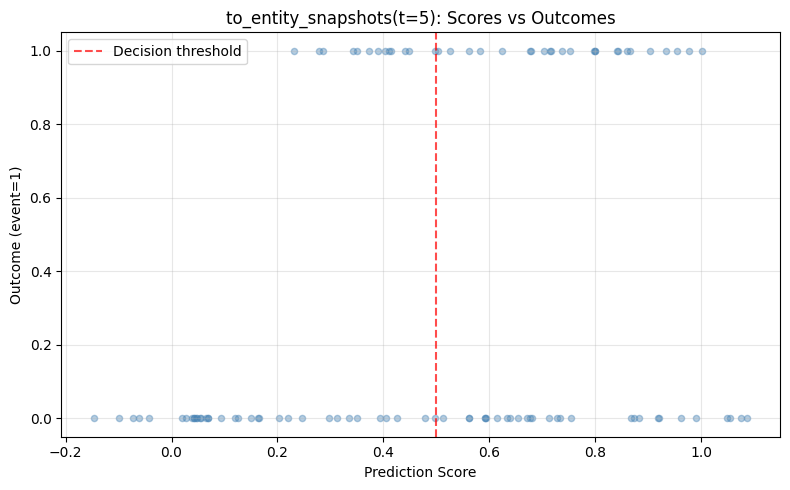

In [6]:
# Snapshot at the first prediction timestep
pred_t = prediction_schedule[0]
snapshot = ds.to_entity_snapshots(t=pred_t)

print(f"Snapshot at t={pred_t}:")
print(f"  entity_ids shape: {snapshot['entity_ids'].shape}")
print(f"  outcomes shape:   {snapshot['outcomes'].shape}")
print(f"  scores type:      {type(snapshot['scores'])}")
if snapshot['scores'] is not None:
    print(f"  scores shape:     {snapshot['scores'].shape}")
    print(f"  scores range:     [{snapshot['scores'].min():.3f}, {snapshot['scores'].max():.3f}]")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(
        snapshot['scores'],
        snapshot['outcomes'],
        alpha=0.4, s=20, color='steelblue'
    )
    ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Decision threshold')
    ax.set_xlabel('Prediction Score')
    ax.set_ylabel('Outcome (event=1)')
    ax.set_title(f'to_entity_snapshots(t={pred_t}): Scores vs Outcomes')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("  No scores available at this timestep")

## Key Insights

1. **`SimulationResults.to_analysis()`** converts raw results into an `AnalysisDataset` with 4 export methods.
2. **`to_time_series()`** returns aggregated outcome series for ITS analysis — one row per timestep, with treatment indicators.
3. **`to_panel()`** returns entity-level panel data for DiD analysis — shape is `n_entities * n_timesteps`, with entity IDs, timesteps, outcomes, and treated flags.
4. **`to_entity_snapshots(t)`** returns cross-sectional data at a single timestep for RDD — entity-level scores and outcomes at the decision boundary.
5. A fourth method, **`to_subgroup_panel()`**, extends the panel with group labels for equity analysis (not shown here).
6. All exports are branch-aware: pass `branch='counterfactual'` to get the counterfactual trajectory.

**Next:** NB08 — Stroke Scenario Integration